# Student Performance Analysis 
---

The objective of this project is to analyze the student-por dataset to identify the key academic, social, and demographic factors that influence student performance in secondary education. By examining patterns and relationships within the data, the project aims to extract meaningful insights that can help understand the determinants of student achievement in Portuguese schools.

---
 

### Step - 1 : Importing the required libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

### Step - 2 : Data Loading

We load the dataset to examine student demographics, academic scores, and social factors that may influence performance.


In [2]:
df = pd.read_csv('student-por.csv')

### Step - 3 : Data Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

 - From the inspection, we observe that the dataset contains the demographic, academic and social variables. The data is a mix of numerical and categorical values. There are no missing values, making it suitable for further analysis. 


### Step - 4 : Initial Understanding

#### 4.1 Preview the data:


In [4]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,2,other,other,...,4,3,2,1,2,5,0,11,13,13


- This provides a snapshot of the dataset, helping to understand its structure and sample values of the variables.

#### 4.2 Data size:

In [5]:
df.shape

(649, 33)

- The dataset contains 649 rows and 33 columns, representing the number of students and their associated attributes.

#### 4.3 Statistical Summary:

In [6]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.305085,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099658,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


- The statistical summary highlights the distribution, central tendency, and variability of numerical variables such as grades, absences, and study time.

### Step - 5: Feature Categorization

To better understand the dataset, variables are grouped into the following categories:
- **Demographic:** sex, age, school
- **Academic:** studytime, failures, absences, G1, G2, G3
- **Family & Support:** famsup, Medu, Fedu, Mjob, Fjob, famsize, guardian
- **Lifestyle & Social:** Dalc, Walc, internet, goout


### Step – 6: Exploratory Data Analysis (EDA)

This section explores key questions to identify relationships between student performance and various demographic, academic, and social factors.


#### Q.1. Average final score (G3) by gender

sex
F    12.253264
M    11.406015
Name: G3, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_17488\775934004.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_avg.index, y=gender_avg.values, palette='pastel')


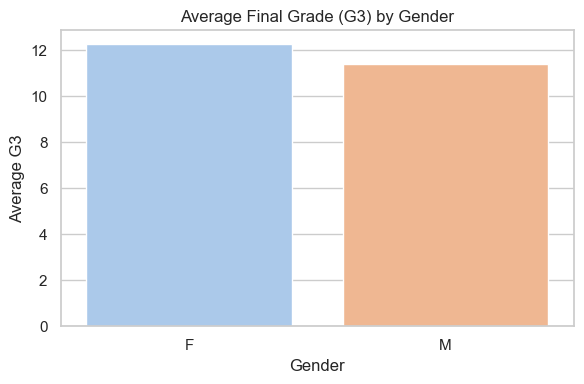

In [7]:
gender_avg = df.groupby('sex')['G3'].mean()
print(gender_avg)
 
plt.figure(figsize=(6, 4))
sns.barplot(x=gender_avg.index, y=gender_avg.values, palette='pastel')
plt.title("Average Final Grade (G3) by Gender")
plt.xlabel("Gender")
plt.ylabel("Average G3")
plt.tight_layout()
plt.savefig("Q1_gender_vs_g3.png")
plt.show()
 

Female students have a slightly higher average final score (G3) compared to male students. 
This indicates a modest difference in academic performance by gender.


#### Q.2. Does study time affect final grades?

<Axes: xlabel='studytime_label'>

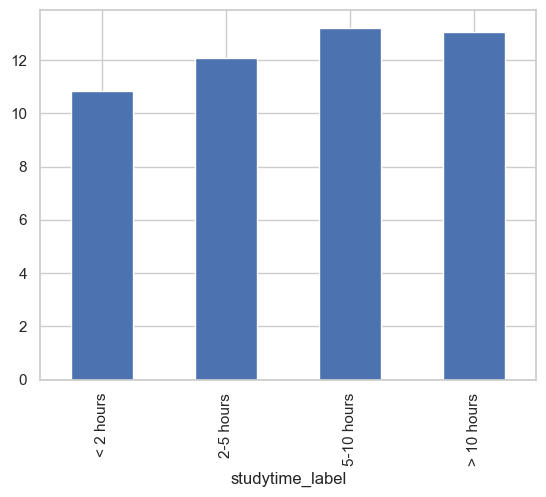

In [8]:
studytime_map = {
    1: '< 2 hours',
    2: '2-5 hours',
    3: '5-10 hours',
    4: '> 10 hours'
}
order = ['< 2 hours', '2-5 hours', '5-10 hours', '> 10 hours']
df.assign(studytime_label=df['studytime'].map(studytime_map)).groupby('studytime_label')['G3'].mean().loc[order].plot(kind = 'bar')



Students with higher study time tend to have higher average final grades, suggesting a positive association between the amount of time spent studying and academic performance.

 Although the increase is not perfectly linear, higher study time categories generally show better average grades.


#### Q.3. Do students with internet access perform better?

In [9]:
df.groupby('internet')['G3'].mean()

internet
no     11.026490
yes    12.172691
Name: G3, dtype: float64

Students with internet access tend to have higher average final grades compared to those without internet access. This indicates a positive association between internet access and academic performance.


#### Q.4. What is the impact of parental education on grades

In [10]:
df.groupby('Fedu')['G3'].mean()

Fedu
0    12.142857
1    10.936782
2    11.790476
3    12.376923
4    12.921875
Name: G3, dtype: float64

In [11]:
df.groupby('Medu')['G3'].mean()

Medu
0    11.666667
1    10.797203
2    11.661290
3    11.920863
4    13.068571
Name: G3, dtype: float64

Student final grades show a positive association with both parents’ education levels. 
However, the association appears slightly stronger for mother’s education, as higher maternal education levels correspond to higher average final grades compared to paternal education.


#### Q.5. What is the relationship between student absences and academic performance?

In [12]:
bins = [0,5, 10, 20, 40]
labels = ['0-5', '5-10', '10-20', '20-40']
df.assign(absences_label = pd.cut(df['absences'], bins=bins, labels=labels)).groupby('absences_label')['G3'].agg(['count','mean'])


C:\Users\Dell\AppData\Local\Temp\ipykernel_17488\146551002.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.assign(absences_label = pd.cut(df['absences'], bins=bins, labels=labels)).groupby('absences_label')['G3'].agg(['count','mean'])


,count,mean
absences_label,,
0-5,234,12.055556
5-10,122,11.852459
10-20,41,10.634146
20-40,8,10.750000


The analysis shows a negative relationship between student absences and final grades. Students in the lowest absence range (0–5) have the highest average final grades, while those in higher absence ranges generally tend to have lower average scores.

Although the highest absence range (20–40) shows a slight increase in average grades, this category contains very few students. Therefore, the results for this group should be interpreted with caution.

#### Q.6. How does alcohol consumption relate to students’ grades?

In [13]:
alc_map = {
    1: 'Very Low',
    2: 'Low',
    3: 'Moderate',
    4: 'High',
    5: 'Very High'
}
order = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
df.assign(Dalc_label = df['Dalc'].map(alc_map)).groupby('Dalc_label')['G3'].agg(['count','mean']).loc[order]


,count,mean
Dalc_label,,
Very Low,451,12.299335
Low,121,11.363636
Moderate,43,11.139535
High,17,8.941176
Very High,17,10.235294


In [14]:
df.assign(Walc_label = df['Walc'].map(alc_map)).groupby('Walc_label')['G3'].agg(['count','mean']).loc[order]

,count,mean
Walc_label,,
Very Low,247,12.360324
Low,150,12.260000
Moderate,120,11.666667
High,87,11.034483
Very High,45,10.555556


The analysis indicates a negative association between alcohol consumption and academic performance. 
Students with very low and low levels of alcohol consumption tend to have higher average final grades, 
while average grades generally decline as alcohol consumption increases.

This pattern is observed for both weekday (Dalc) and weekend (Walc) alcohol consumption, with the 
decline being more pronounced for weekend alcohol use. However, higher consumption categories 
contain fewer students, so the results for these groups should be interpreted with caution.


#### Q.7. Is there a difference in academic performance across schools?

In [15]:
df.groupby('school')['G3'].agg(['count', 'mean'])

,count,mean
school,,
GP,423,12.576832
MS,226,10.650442


The analysis indicates that there is a difference in academic performance across schools. 
Students from school GP have a higher average final grade compared to students from school MS. 
This suggests that school-level factors, such as teaching methods, resources, or environment, 
may influence student performance. However, the difference is modest and should be interpreted 
as a trend rather than a definitive cause

#### Q.8. Does family support influence student performance?

In [16]:
df.groupby('famsup')['G3'].agg(['count','mean'])

,count,mean
famsup,,
no,251,11.665339
yes,398,12.057789


The analysis shows a modest difference between the average final grades. Students with family support generally score  higher compared to the students with no family support suggesting a positive association between family support and final grades.

## Step - 7: Final Insights

- Female students tend to have slightly higher average final grades compared to male students.
- Increased study time is generally associated with better academic performance.
- Students with internet access show marginally higher average grades.
- Higher parental education levels, particularly maternal education, are associated with better student outcomes.
- Student absences show a negative relationship with academic performance; higher absenteeism corresponds to lower average grades.
- Higher levels of alcohol consumption are associated with lower academic performance, with weekend alcohol consumption showing a stronger effect.
- Academic performance varies slightly across schools, suggesting school-level factors may influence outcomes.
- Students with family support tend to perform marginally better academically, though the difference is modest.
